In [ ]:
# Load and inspect the generated SUMO network, get number of edges and junctions
import sumolib
import os

notebook_dir = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
project_root = os.path.dirname(notebook_dir)

net_file = os.path.join(project_root, "sumo", "network", "osm.net.xml.gz")
net = sumolib.net.readNet(net_file)

print(f"Number of edges: {len(net.getEdges())}")
print(f"Number of junctions: {len(net.getNodes())}")

Number of edges: 1721
Number of junctions: 941


In [27]:
# List all traffic light junctions
tls_junctions = [node for node in net.getNodes() if node.getType() == "traffic_light"]
print(f"Number of TLS junctions: {len(tls_junctions)}")
for node in tls_junctions:
    coord = node.getCoord()
    print(f" {node.getID():40s} ({coord[0]:.4f}, {coord[1]:.4f})")

Number of TLS junctions: 13
 cluster_21631723_393551231_393552095_401526123_#1more (197.5700, 404.8600)
 cluster_29696843_393551252_393552059_394512440_#1more (1368.7500, 650.6100)
 cluster_29604747_393551251_393552061_394502530_#1more (1176.2100, 591.9800)
 cluster_11149179983_29604800_393551254_393552055_#1more (1459.2700, 672.2700)
 cluster_34600564_391169142_391175820_393546103_#5more (1619.2800, 711.4800)
 cluster_1369085152_1369085197_29604707_393551250_#1more (990.8800, 535.5400)
 cluster_25629241_25629242_393547020_393547032_#4more (839.0500, 488.0700)
 cluster_2675699373_2675699383_2675699394_2675699404_#3more (787.0800, 648.6700)
 cluster_29604657_3240419088_3240419089_393551241_#1more (501.5900, 381.8600)
 cluster_29605017_769486879               (1693.2600, 533.3500)
 cluster_29605016_769486906               (1666.9400, 524.8000)
 cluster_29604992_393547022_402129043_402129047_#1more (911.9300, 265.3300)
 29604669                                 (730.8100, 807.7300)


In [28]:
# List all edges (roads)
for edge in net.getEdges()[:20]:  # first 20
    print(
        f"Edge {edge.getID()}: {edge.getLaneNumber()} lanes, {edge.getLength():.1f}m, speed {edge.getSpeed():.1f} m/s"
    )

Edge -10070530#0: 1 lanes, 0.1m, speed 5.6 m/s
Edge -10070530#1: 1 lanes, 39.6m, speed 5.6 m/s
Edge -10070530#4: 1 lanes, 12.6m, speed 5.6 m/s
Edge -10070531#1: 1 lanes, 30.2m, speed 5.6 m/s
Edge -10070531#2: 1 lanes, 30.8m, speed 5.6 m/s
Edge -10070533#0: 1 lanes, 64.7m, speed 5.6 m/s
Edge -10070533#4: 1 lanes, 34.8m, speed 5.6 m/s
Edge -10070534: 1 lanes, 32.1m, speed 8.3 m/s
Edge -10070538#1: 1 lanes, 104.9m, speed 5.6 m/s
Edge -10070541#1: 1 lanes, 56.5m, speed 5.6 m/s
Edge -10070548#0: 1 lanes, 0.2m, speed 5.6 m/s
Edge -10070548#1: 1 lanes, 31.2m, speed 5.6 m/s
Edge -10070550#0: 1 lanes, 24.0m, speed 5.6 m/s
Edge -10070550#1: 1 lanes, 31.9m, speed 5.6 m/s
Edge -10070554#1: 1 lanes, 43.6m, speed 5.6 m/s
Edge -10070554#2: 1 lanes, 27.4m, speed 5.6 m/s
Edge -10070554#3: 1 lanes, 3.0m, speed 5.6 m/s
Edge -10070555#1: 1 lanes, 63.6m, speed 5.6 m/s
Edge -10070562#0: 1 lanes, 3.9m, speed 8.3 m/s
Edge -10070562#1: 1 lanes, 81.0m, speed 8.3 m/s


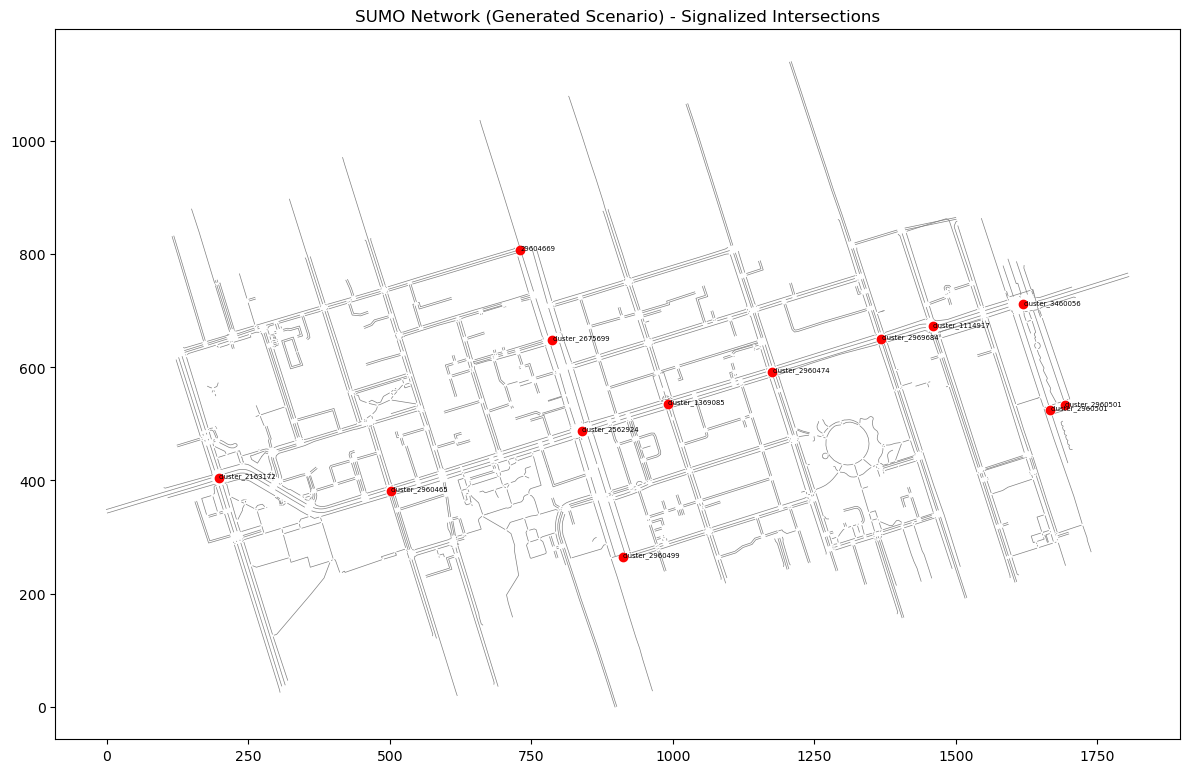

In [29]:
# Visualize the network
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 8))
for edge in net.getEdges():
    shape = edge.getShape()
    xs = [p[0] for p in shape]
    ys = [p[1] for p in shape]
    ax.plot(xs, ys, "gray", linewidth=0.5)

for node in tls_junctions:
    coord = node.getCoord()
    ax.plot(coord[0], coord[1], "ro", markersize=6)
    ax.annotate(node.getID()[:15], (coord[0], coord[1]), fontsize=5)

ax.set_title("SUMO Network (Generated Scenario) - Signalized Intersections")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(os.path.join(project_root, "docs", "network_map.png"), dpi=150)
plt.show()